# Delivery Time Analysis


In [232]:
# CELL 1: SETUP & IMPORT

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', None)

file_path = "cleaned_dynamic_supply_chain_logistics_dataset.csv"
df = pd.read_csv(file_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Dataset loaded successfully!")
print(f"Rows: {len(df):,} | Columns: {len(df.columns)}")
df.head(3)

Dataset loaded successfully!
Rows: 32,065 | Columns: 41


,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,is_peak_hour,traffic_intensity_proxy,route_complexity,lat_bin,long_bin,gps_zone,delivery_zone_density,distance_proxy_x_peak_hour,traffic_x_weather,traffic_x_route_risk
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0,0.0,3.566787,2,4,2_4,1590,0.0,2.128395,7.007094
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,0,0.0,4.503525,0,0,0_0,2701,0.0,0.367208,15.302210
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,0,0.0,5.210099,0,4,0_4,5252,0.0,0.239116,57.739408


## Create general analysis columns

In [233]:
# CELL 2: FEATURE ENGINEERING

# --- Time block (hour)
hour = df['timestamp'].dt.hour
df['time_block'] = np.select(
    [hour.between(6, 9), hour.between(16, 19), hour.between(10, 15)],
    ['Morning Peak (6h-9h)', 'Evening Peak (16h-19h)', 'Normal Operating Hours'],
    default='Off-Peak Hours'
)

# --- Vehicle group theo driver_behavior_score (NTILE 3)
df['vehicle_group'] = pd.qcut(
    df['driver_behavior_score'], q=3,
    labels=['Low Driver Performance', 'Medium Driver Performance', 'High Driver Performance']
)

# --- Zone: chia 4 nhom theo median lat/long thuc te cua data
lat_mid  = df['vehicle_gps_latitude'].median()
long_mid = df['vehicle_gps_longitude'].median()
df['zone'] = np.select(
    [
        (df['vehicle_gps_latitude'] >= lat_mid)  & (df['vehicle_gps_longitude'] >= long_mid),
        (df['vehicle_gps_latitude'] >= lat_mid)  & (df['vehicle_gps_longitude'] <  long_mid),
        (df['vehicle_gps_latitude'] <  lat_mid)  & (df['vehicle_gps_longitude'] >= long_mid),
    ],
    ['Northeast Zone', 'Northwest Zone', 'Southeast Zone'],
    default='Southwest Zone'
)

# --- Late delivery flag
df['is_late'] = (df['delivery_time_deviation'] > 0).astype(int)

# --- Route label (gop 3 chieu)
df['route'] = (
    df['risk_classification'].astype(str) + ' | ' +
    df['time_block'] + ' | ' +
    df['vehicle_group'].astype(str)
)

print("Feature engineering ready")
display(df[['time_block', 'vehicle_group', 'zone', 'is_late', 'route']].head(3))

Feature engineering ready


,time_block,vehicle_group,zone,is_late,route
0,Off-Peak Hours,Low Driver Performance,Northeast Zone,1,Moderate Risk | Off-Peak Hours | Low Driver Performance
1,Off-Peak Hours,Low Driver Performance,Southwest Zone,1,High Risk | Off-Peak Hours | Low Driver Performance
2,Off-Peak Hours,Medium Driver Performance,Southeast Zone,1,High Risk | Off-Peak Hours | Medium Driver Performance


## Load data into SQLite

In [234]:
# CELL 3: Load data into SQLite (in-memory)

conn = sqlite3.connect(':memory:')
df.to_sql('deliveries', conn, if_exists='replace', index=False)
cur = conn.cursor()

cur.execute("SELECT COUNT(*) FROM deliveries")
print(f"SQLite loaded: {cur.fetchone()[0]:,} records")
cur.execute("SELECT name FROM pragma_table_info('deliveries') LIMIT 10")
print("Sample columns:", [r[0] for r in cur.fetchall()])

SQLite loaded: 32,065 records
Sample columns: ['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability', 'order_fulfillment_status']


## QUERY 1 — Avg Delivery Time theo Distance
> 


,distance_group,total_records,avg_distance_proxy_km,avg_final_delivery_time_hours,avg_eta_variation_hours,avg_delay_probability
0,Long (400-800 km),4776,478.56,12.31,-0.3082,0.7082
1,Medium (200-400 km),19224,282.50,8.89,3.1105,0.6972
2,Short (< 200 km),8065,154.59,7.73,4.2706,0.6981


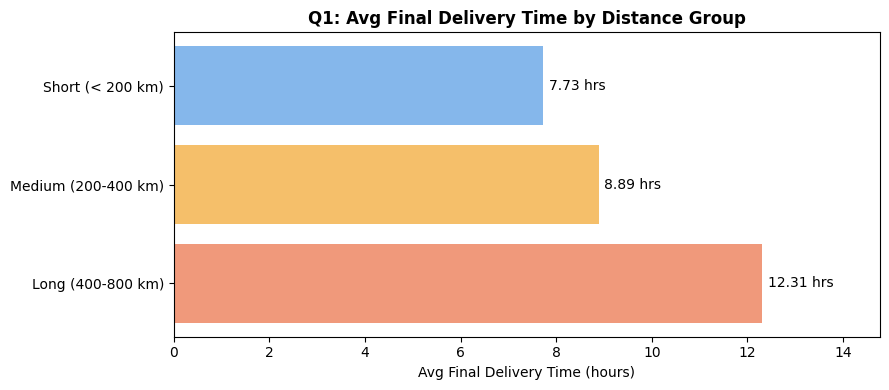

In [235]:
# QUERY 1: AVG DELIVERY TIME BY DISTANCE PROXY

sql_q1 = """
SELECT
    CASE
        WHEN distance_proxy < 200  THEN 'Short (< 200 km)'
        WHEN distance_proxy < 400  THEN 'Medium (200-400 km)'
        Else                            'Long (400-800 km)'
                                    
    END AS distance_group,
    COUNT(*) AS total_records,
    ROUND(AVG(distance_proxy), 2)            AS avg_distance_proxy_km,
    ROUND(AVG(final_delivery_time_hours), 2) AS avg_final_delivery_time_hours,
    ROUND(AVG(eta_variation_hours), 4)       AS avg_eta_variation_hours,
    ROUND(AVG(delay_probability), 4)         AS avg_delay_probability
    
FROM (
    SELECT *,
        (12 - eta_variation_hours) AS final_delivery_time_hours,
        (12 - eta_variation_hours) * CASE
            WHEN traffic_congestion_level >= 7.0 THEN 20
            WHEN traffic_congestion_level >= 4.0 THEN 30
            ELSE 40
        END AS distance_proxy
    FROM deliveries
) t
GROUP BY distance_group
ORDER BY avg_distance_proxy_km DESC
"""

q1 = pd.read_sql(sql_q1, conn)
display(q1)

# VISUALIZATION
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(
    q1['distance_group'],
    q1['avg_final_delivery_time_hours'],
    color=['#F0997B', '#F5BF6A', '#85B7EB', '#97C459'][:len(q1)]
)
ax.bar_label(bars, fmt='%.2f hrs', padding=4, fontsize=10)
ax.set_xlabel('Avg Final Delivery Time (hours)')
ax.set_title('Q1: Avg Final Delivery Time by Distance Group', fontweight='bold')
ax.set_xlim(0, q1['avg_final_delivery_time_hours'].max() * 1.2)
plt.tight_layout()
plt.show()

## QUERY 2 — Avg Delivery Time theo Hour (Time Block)

,time_block,total_orders,avg_eta_variation_hours,avg_traffic_congestion,estimated_actual_delivery_hours,avg_hours_over_deadline,late_rate_pct
0,Morning Peak (6h-9h),5344,2.86,5.06,14.21,3.07,66.93
1,Evening Peak (16h-19h),5344,2.85,4.90,14.04,2.96,65.14
2,Normal Operating Hours,8016,2.90,4.94,9.10,0.19,16.54
3,Off-Peak Hours,13361,2.92,5.03,9.08,0.19,16.97


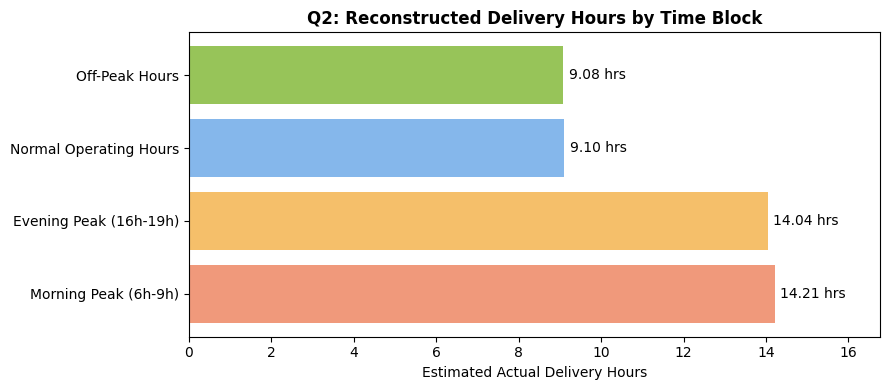

In [236]:
# SQL QUERY
sql_q2 = """
SELECT
    time_block,
    COUNT(*) AS total_orders,
    ROUND(AVG(eta_variation_hours), 2) AS avg_eta_variation_hours,
    ROUND(AVG(traffic_congestion_level), 2) AS avg_traffic_congestion,

    ROUND(AVG(
        12 - eta_variation_hours +
        CASE WHEN time_block IN ('Morning Peak (6h-9h)', 'Evening Peak (16h-19h)')
             THEN traffic_congestion_level ELSE 0 END
    ), 2) AS estimated_actual_delivery_hours,

    ROUND(AVG(
        CASE WHEN (12 - eta_variation_hours +
                   CASE WHEN time_block IN ('Morning Peak (6h-9h)', 'Evening Peak (16h-19h)')
                        THEN traffic_congestion_level ELSE 0 END) > 12
             THEN CASE WHEN time_block IN ('Morning Peak (6h-9h)', 'Evening Peak (16h-19h)')
                       THEN traffic_congestion_level - eta_variation_hours
                       ELSE -eta_variation_hours END
             ELSE 0 END
    ), 2) AS avg_hours_over_deadline,

    ROUND(SUM(
        CASE WHEN (12 - eta_variation_hours +
                   CASE WHEN time_block IN ('Morning Peak (6h-9h)', 'Evening Peak (16h-19h)')
                        THEN traffic_congestion_level ELSE 0 END) > 12
             THEN 1 ELSE 0 END
    ) * 100.0 / COUNT(*), 2) AS late_rate_pct

FROM deliveries
GROUP BY time_block
ORDER BY estimated_actual_delivery_hours DESC
"""

# LOAD DATA
q2 = pd.read_sql(sql_q2, conn)
display(q2)

# VISUALIZATION
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#F0997B', '#F5BF6A', '#85B7EB', '#97C459']

bars = ax.barh(q2['time_block'], q2['estimated_actual_delivery_hours'], color=colors[:len(q2)])
ax.bar_label(bars, fmt='%.2f hrs', padding=4, fontsize=10)
ax.set_xlabel('Estimated Actual Delivery Hours')
ax.set_title('Q2: Reconstructed Delivery Hours by Time Block', fontweight='bold')
ax.set_xlim(0, q2['estimated_actual_delivery_hours'].max() * 1.18)
plt.tight_layout()
plt.show()



## QUERY 3 — Average Delivery Time by Vehicle (Driver Performance)

,vehicle_group,total_records,avg_lead_time_days,avg_delivery_deviation,avg_delay_probability,avg_fuel_consumption,avg_driver_fatigue,avg_loading_time
0,Low Driver Performance,10689,5.2816,5.1991,0.6988,8.0102,0.5981,2.2911
1,Medium Driver Performance,10688,5.2597,5.1734,0.7039,8.0016,0.6018,2.2979
2,High Driver Performance,10688,5.1412,5.1604,0.6945,8.0234,0.6027,2.2860


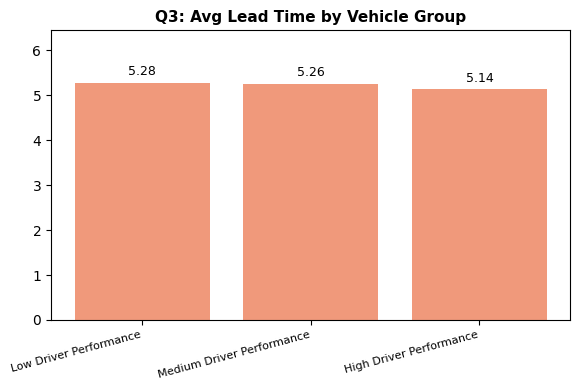

In [237]:
# QUERY 3: Average Delivery Time by Vehicle

sql_q3 = """
SELECT
    vehicle_group,
    COUNT(*)                                  AS total_records,
    ROUND(AVG(lead_time_days), 4)             AS avg_lead_time_days,
    ROUND(AVG(delivery_time_deviation), 4)    AS avg_delivery_deviation,
    ROUND(AVG(delay_probability), 4)          AS avg_delay_probability,
    ROUND(AVG(fuel_consumption_rate), 4)      AS avg_fuel_consumption,
    ROUND(AVG(fatigue_monitoring_score), 4)   AS avg_driver_fatigue,
    ROUND(AVG(loading_unloading_time), 4)     AS avg_loading_time
FROM deliveries
GROUP BY vehicle_group
ORDER BY avg_lead_time_days DESC
"""

q3 = pd.read_sql(sql_q3, conn)
display(q3)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(q3['vehicle_group'], q3['avg_lead_time_days'], color='#F0997B')
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_title('Q3: Avg Lead Time by Vehicle Group', fontsize=11, fontweight='bold')
ax.set_xticklabels(q3['vehicle_group'], rotation=15, ha='right', fontsize=8)
ax.set_ylim(0, q3['avg_lead_time_days'].max() * 1.22)
plt.tight_layout()
plt.show()



## QUERY 4 — Late Delivery Rate theo Zone

,zone,total_records,late_count,reconstructed_late_rate_pct,avg_last_mile_delivery_hours,avg_eta_variation_hours,avg_traffic_congestion,avg_delivery_deviation,avg_delay_probability
0,Southwest Zone,8054,2695,33.46,10.77,2.85,4.99,5.20,0.6995
1,Northwest Zone,7978,2649,33.20,10.79,2.91,5.05,5.18,0.6976
2,Northeast Zone,8055,2668,33.12,10.75,2.90,4.97,5.16,0.6991
3,Southeast Zone,7978,2640,33.09,10.76,2.91,4.96,5.17,0.7001


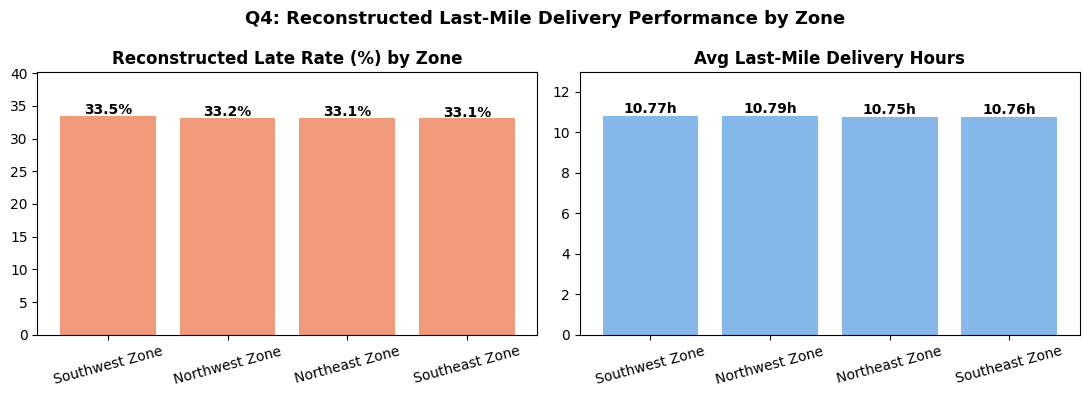

In [238]:
# QUERY 4: RECONSTRUCTED LAST-MILE DELIVERY ANALYSIS BY ZONE

sql_q4 = """
WITH reconstructed AS (
    SELECT
        zone, time_block, eta_variation_hours, traffic_congestion_level,
        delivery_time_deviation, delay_probability,
        CASE WHEN time_block IN ('Morning Peak (6h-9h)', 'Evening Peak (16h-19h)')
             THEN 12 - eta_variation_hours + traffic_congestion_level
             ELSE 12 - eta_variation_hours
        END AS reconstructed_delivery_hours
    FROM deliveries
)
SELECT
    zone,
    COUNT(*) AS total_records,
    SUM(CASE WHEN reconstructed_delivery_hours > 12 THEN 1 ELSE 0 END) AS late_count,
    ROUND(SUM(CASE WHEN reconstructed_delivery_hours > 12 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS reconstructed_late_rate_pct,
    ROUND(AVG(reconstructed_delivery_hours), 2)  AS avg_last_mile_delivery_hours,
    ROUND(AVG(eta_variation_hours), 2)            AS avg_eta_variation_hours,
    ROUND(AVG(traffic_congestion_level), 2)       AS avg_traffic_congestion,
    ROUND(AVG(delivery_time_deviation), 2)        AS avg_delivery_deviation,
    ROUND(AVG(delay_probability), 4)              AS avg_delay_probability
FROM reconstructed
GROUP BY zone
ORDER BY reconstructed_late_rate_pct DESC
"""

# LOAD DATA
q4 = pd.read_sql(sql_q4, conn)
display(q4)

# VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, color, title, fmt, pad in zip(
    axes,
    ['reconstructed_late_rate_pct', 'avg_last_mile_delivery_hours'],
    ['#F0997B', '#85B7EB'],
    ['Reconstructed Late Rate (%) by Zone', 'Avg Last-Mile Delivery Hours'],
    ['{:.1f}%', '{:.2f}h'],
    [0.3, 0.15]
):
    ax.bar(q4['zone'], q4[col], color=color)
    for i, v in enumerate(q4[col]):
        ax.text(i, v + pad, fmt.format(v), ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, q4[col].max() * 1.2)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Q4: Reconstructed Last-Mile Delivery Performance by Zone', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



## QUERY 5 — Correlation: Distance vs Delivery Duration

,Method,Correlation_r,P_value,Significant,Interpretation
0,Pearson,-0.0051,0.357179,False,weak
1,Spearman,-0.0087,0.120439,False,weak


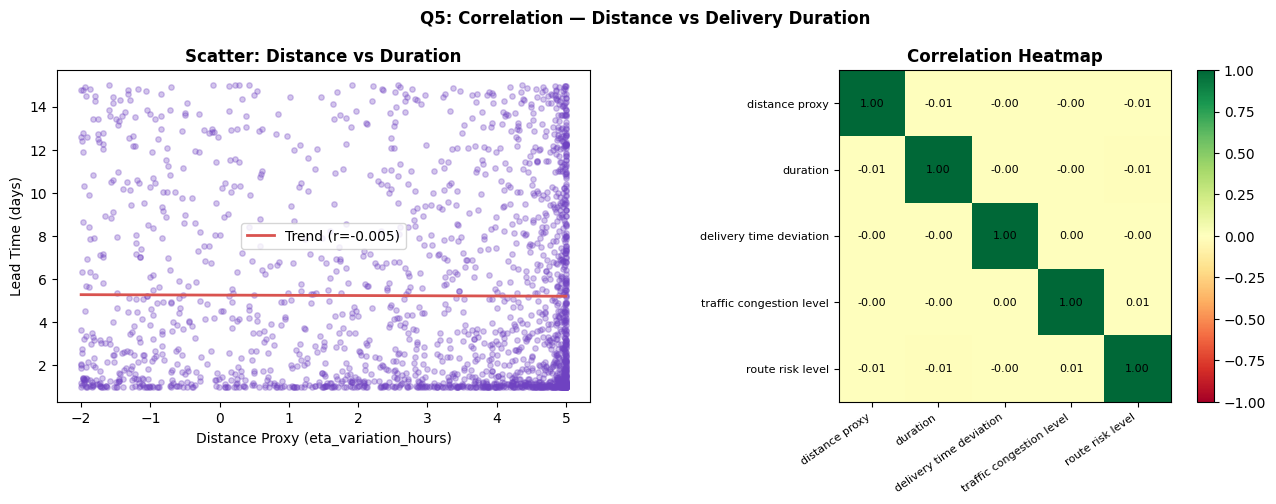

Pearson r = -0.0051 | Spearman r = -0.0087


In [239]:
# QUERY 5: Fetch data from SQL -> Calculate correlation with Python

sql_q5 = """
SELECT
    eta_variation_hours     AS distance_proxy,
    lead_time_days          AS duration,
    delivery_time_deviation,
    traffic_congestion_level,
    route_risk_level
FROM deliveries
WHERE eta_variation_hours IS NOT NULL
  AND lead_time_days IS NOT NULL
"""

q5 = pd.read_sql(sql_q5, conn)

# Pearson & Spearman
pearson_r,  p_pearson  = stats.pearsonr(q5['distance_proxy'], q5['duration'])
spearman_r, p_spearman = stats.spearmanr(q5['distance_proxy'], q5['duration'])

corr_result = pd.DataFrame({
    'Method'        : ['Pearson', 'Spearman'],
    'Correlation_r' : [round(pearson_r, 4), round(spearman_r, 4)],
    'P_value'       : [round(p_pearson, 6), round(p_spearman, 6)],
    'Significant'   : [p_pearson < 0.05, p_spearman < 0.05],
    'Interpretation': [
        'Manh' if abs(pearson_r)  > 0.7 else ('Average' if abs(pearson_r)  > 0.4 else 'weak'),
        'Manh' if abs(spearman_r) > 0.7 else ('Average' if abs(spearman_r) > 0.4 else 'weak')
    ]
})
display(corr_result)

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sample = q5.sample(min(2000, len(q5)), random_state=42)
axes[0].scatter(sample['distance_proxy'], sample['duration'],
                alpha=0.3, color='#6f42c1', s=15)
m, b = np.polyfit(q5['distance_proxy'], q5['duration'], 1)
x_line = np.linspace(q5['distance_proxy'].min(), q5['distance_proxy'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='#d9534f', linewidth=2, label=f'Trend (r={pearson_r:.3f})')
axes[0].set_xlabel('Distance Proxy (eta_variation_hours)')
axes[0].set_ylabel('Lead Time (days)')
axes[0].set_title('Scatter: Distance vs Duration', fontweight='bold')
axes[0].legend()

cols_heat = ['distance_proxy', 'duration', 'delivery_time_deviation',
             'traffic_congestion_level', 'route_risk_level']
corr_mat = q5[cols_heat].corr()
im = axes[1].imshow(corr_mat, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[1])
axes[1].set_xticks(range(len(cols_heat)))
axes[1].set_yticks(range(len(cols_heat)))
axes[1].set_xticklabels([c.replace('_', ' ') for c in cols_heat], rotation=35, ha='right', fontsize=8)
axes[1].set_yticklabels([c.replace('_', ' ') for c in cols_heat], fontsize=8)
for i in range(len(cols_heat)):
    for j in range(len(cols_heat)):
        axes[1].text(j, i, f'{corr_mat.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
axes[1].set_title('Correlation Heatmap', fontweight='bold')

plt.suptitle('Q5: Correlation — Distance vs Delivery Duration', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Pearson r = {pearson_r:.4f} | Spearman r = {spearman_r:.4f}")


## QUERY 6 — Aggregate by Popular Routes (Top 20)

,zone,total_records,avg_lead_time_days,avg_deviation_hours,avg_delay_prob,avg_shipping_cost,avg_fuel_rate,avg_traffic,late_count,late_rate_pct
0,0_4,5252,5.3292,5.1958,0.6970,463.4235,7.9814,4.9524,3805,72.4
1,0_0,2701,5.1571,5.1746,0.7042,459.6380,8.0482,5.0961,1972,73.0
2,4_4,2680,5.2777,5.2329,0.6910,459.8055,7.9451,4.8853,1918,71.6
3,1_4,1894,5.1281,5.1955,0.7071,462.5770,7.9937,4.9754,1402,74.0
4,0_3,1860,5.4384,5.0872,0.6966,470.4796,8.1822,4.9252,1337,71.9
5,0_2,1594,5.1750,5.3489,0.7000,461.9894,8.1498,4.9376,1168,73.3
6,2_4,1590,5.2758,5.0879,0.7070,458.0184,7.8620,5.0747,1182,74.3
7,3_4,1588,5.0856,5.0651,0.7045,457.8033,7.9781,4.9714,1169,73.6
8,0_1,1562,5.2426,5.1813,0.7014,453.7170,8.0636,5.0480,1146,73.4
9,4_0,1328,5.3093,5.2211,0.6944,443.4268,7.8178,5.0606,962,72.4


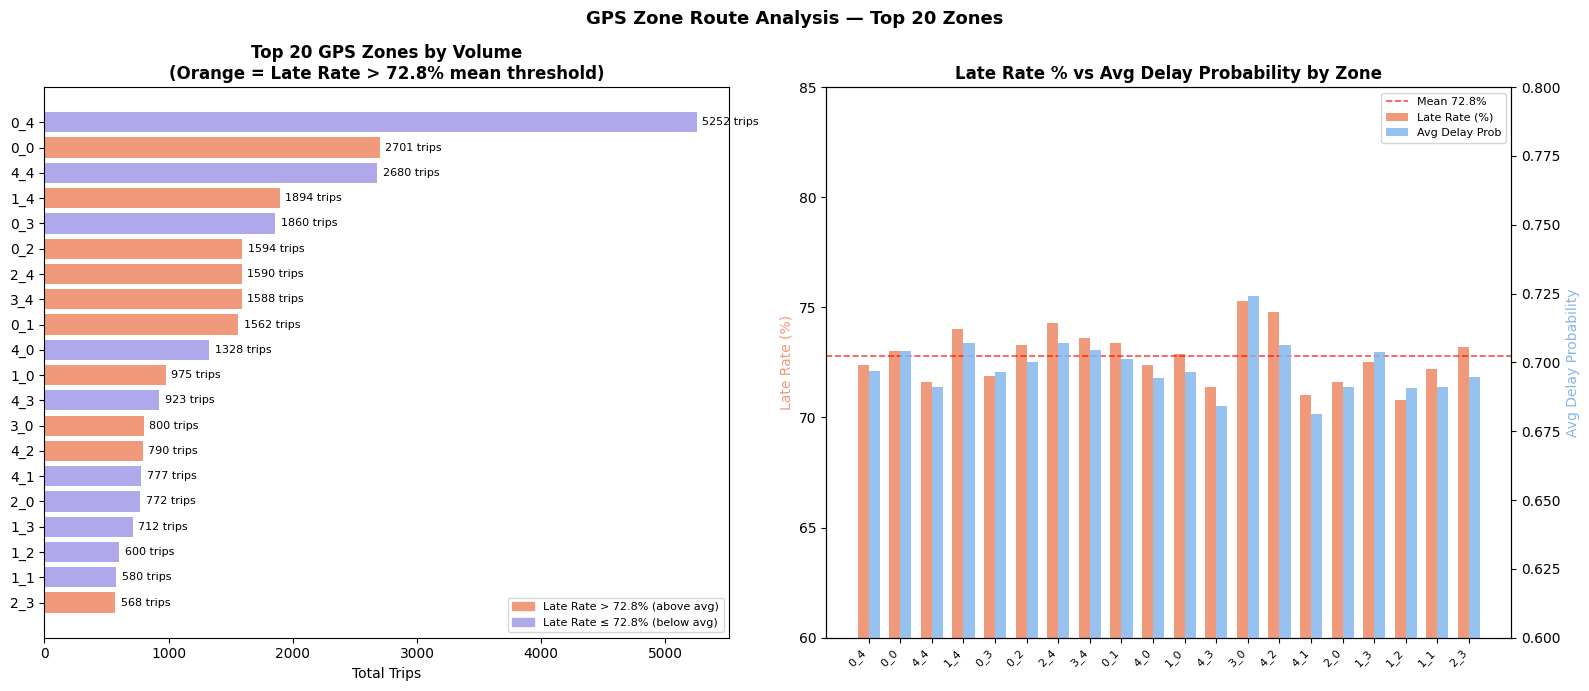

In [ ]:
# QUERY 6 : TOP 20 GPS ZONES — proxy for popular routes

 
sql_q6 = """
SELECT
    gps_zone                                            AS zone,
    COUNT(*)                                            AS total_records,
    ROUND(AVG(lead_time_days), 4)                       AS avg_lead_time_days,
    ROUND(AVG(delivery_time_deviation), 4)              AS avg_deviation_hours,
    ROUND(AVG(delay_probability), 4)                    AS avg_delay_prob,
    ROUND(AVG(shipping_costs), 4)                       AS avg_shipping_cost,
    ROUND(AVG(fuel_consumption_rate), 4)                AS avg_fuel_rate,
    ROUND(AVG(traffic_congestion_level), 4)             AS avg_traffic,
    SUM(CASE WHEN delay_probability > 0.5 THEN 1 ELSE 0 END)               AS late_count,
    ROUND(SUM(CASE WHEN delay_probability > 0.5 THEN 1 ELSE 0 END) * 100.0
          / COUNT(*), 1)                                AS late_rate_pct
FROM deliveries
WHERE gps_zone IS NOT NULL
GROUP BY gps_zone
ORDER BY total_records DESC
LIMIT 20
"""
 
q6 = pd.read_sql(sql_q6, conn)
display(q6)
 
mean_late = round(q6['late_rate_pct'].mean(), 1)
colors_bar = ['#F0997B' if r > mean_late else '#AFA9EC' for r in q6['late_rate_pct']]
 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
 
# Plot 1: Total Records — horizontal bar
bars = axes[0].barh(q6['zone'], q6['total_records'], color=colors_bar)
axes[0].bar_label(bars, fmt='%d trips', padding=4, fontsize=8)
axes[0].set_xlabel('Total Trips')
axes[0].set_title(f'Top 20 GPS Zones by Volume\n(Orange = Late Rate > {mean_late}% mean threshold)', fontweight='bold')
axes[0].invert_yaxis()
 
orange_p = mpatches.Patch(color='#F0997B', label=f'Late Rate > {mean_late}% (above avg)')
purple_p = mpatches.Patch(color='#AFA9EC', label=f'Late Rate ≤ {mean_late}% (below avg)')
axes[0].legend(handles=[orange_p, purple_p], fontsize=8, loc='lower right')
 
# Plot 2: Grouped bar Late Rate % + Avg Delay Prob
x     = np.arange(len(q6))
width = 0.35
 
axes[1].bar(x - width / 2, q6['late_rate_pct'], width, color='#F0997B', label='Late Rate (%)')
ax2 = axes[1].twinx()
ax2.bar(x + width / 2, q6['avg_delay_prob'], width, color='#85B7EB', alpha=0.85, label='Avg Delay Prob')
 
axes[1].axhline(mean_late, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label=f'Mean {mean_late}%')
axes[1].set_xticks(x)
axes[1].set_xticklabels(q6['zone'], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Late Rate (%)', color='#F0997B', fontsize=10)
axes[1].set_ylim(60, 85)
ax2.set_ylabel('Avg Delay Probability', color='#85B7EB', fontsize=10)
ax2.set_ylim(0.60, 0.80)
axes[1].set_title('Late Rate % vs Avg Delay Probability by Zone', fontweight='bold')
 
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
 
plt.suptitle('GPS Zone Route Analysis — Top 20 Zones', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Save and Close Connection

In [241]:
conn.close()
print("complete")

complete
